# LIBERO cached-feature audit

This notebook validates the cache **before training**. It checks the four requested suites, tensor schemas and masks, Qwen/T5 features, lossless PNG payloads, exact cache-to-HDF5 state/action alignment, rotation geometry, and the batch that the training collator will produce.

Timestep convention: the HDF5 transition is `state[t] -- actions[t] --> state[t+1]`. If the immediate command after `state[t]` is called `action[t+1]`, it is still stored at HDF5 array index `actions[t]`; the cache must therefore start its 64-command target at array index `t`.

In [1]:
from __future__ import annotations

import html
import io
import json
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, display
from PIL import Image

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root')

REPO_ROOT = find_repo_root(Path.cwd())
for path in (REPO_ROOT, REPO_ROOT / 'src', REPO_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from thinkflow_rdt.adapters.libero import (
    LIBERO_ACTION_DIM,
    LIBERO_STATE_DIM,
    libero_action_to_rdt,
    libero_image_to_rgb,
    libero_orientation_to_ortho6d,
    ortho6d_to_rotation_matrix,
    rdt_action_to_libero,
)
from thinkflow_rdt.config import load_config
from thinkflow_rdt.data import (
    ONLINE_SIGLIP_REQUIRED_KEYS,
    CachedFeatureDataset,
    RDTOnlineSiglipBatchCollator,
)

np.set_printoptions(precision=6, suppress=True)

def show_table(rows: list[dict]) -> None:
    if not rows:
        display(HTML('<em>No rows</em>'))
        return
    columns = list(dict.fromkeys(key for row in rows for key in row))
    def text(value):
        if isinstance(value, float):
            value = f'{value:.7g}'
        return html.escape(str(value))
    header = ''.join(f'<th>{text(column)}</th>' for column in columns)
    body = ''.join(
        '<tr>' + ''.join(f'<td>{text(row.get(column, ""))}</td>' for column in columns) + '</tr>'
        for row in rows
    )
    display(HTML(f'<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>'))
print('Repository:', REPO_ROOT)

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Repository: /home/ubuntu/ThinkFlow-RDT-1B


## Configuration

Change only this cell to inspect another suite, split, shard, or sample. `SOURCE_ROOT_OVERRIDE` can point to the original HDF5 root if metadata contains a path that is unavailable on this machine.

In [2]:
CACHE_ROOT = REPO_ROOT / 'cache_features_libero_b0_raw_ortho6d'
SUITES = ('libero_10', 'libero_spatial', 'libero_goal', 'libero_object')
SELECTED_SUITE = 'libero_object'
SELECTED_SPLIT = 'train'
SELECTED_SHARD_INDEX = 0
LOCAL_SAMPLE_INDEX = 0
SHARDS_PER_SUITE_TO_AUDIT = 10
SOURCE_ROOT_OVERRIDE: Path | None = None
CONFIG_PATH = REPO_ROOT / 'configs/b0_rdt1b_lora.yaml'

assert SELECTED_SUITE in SUITES
assert CACHE_ROOT.exists(), CACHE_ROOT
print('Cache root:', CACHE_ROOT)

Cache root: /home/ubuntu/ThinkFlow-RDT-1B/cache_features_libero_b0_raw_ortho6d


## 1. Discover suites, metadata, and manifest sizes

In [3]:
def read_json(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)

def read_manifest(path: Path) -> list[dict]:
    with path.open('r', encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]

suite_metadata = {}
discovery_rows = []
for suite in SUITES:
    suite_root = CACHE_ROOT / suite
    metadata_path = suite_root / 'precompute_metadata.json'
    assert metadata_path.exists(), metadata_path
    metadata = read_json(metadata_path)
    suite_metadata[suite] = metadata
    for split in ('train', 'validation', 'test'):
        manifest_path = suite_root / split / 'manifest.jsonl'
        assert manifest_path.exists(), manifest_path
        rows = read_manifest(manifest_path)
        discovery_rows.append({
            'suite': suite,
            'split': split,
            'shards': len(rows),
            'samples': sum(int(row.get('num_samples', 1)) for row in rows),
            'state_dim': metadata.get('state_dim'),
            'action_dim': metadata.get('action_dim'),
            'normalized': metadata.get('normalize_actions'),
            'image_codec': metadata.get('image_storage_codec'),
            'lossless': metadata.get('image_storage_lossless'),
        })

show_table(discovery_rows)

for suite, metadata in suite_metadata.items():
    assert metadata['state_dim'] == 11, (suite, metadata['state_dim'])
    assert metadata['action_dim'] == 10, (suite, metadata['action_dim'])
    assert metadata['state_encoder_layout'] == 'libero_ortho6d'
    assert metadata['action_encoder_layout'] == 'libero_ortho6d'
    assert metadata['normalize_actions'] is False
    assert metadata['action_target_mode'] == 'delta'
    assert metadata['image_storage_codec'] == 'png'
    assert metadata['image_storage_lossless'] is True
print('Metadata contract: PASS')

suite,split,shards,samples,state_dim,action_dim,normalized,image_codec,lossless
libero_10,train,3374,107925,11,10,False,png,True
libero_10,validation,450,14345,11,10,False,png,True
libero_10,test,497,15820,11,10,False,png,True
libero_spatial,train,1624,51916,11,10,False,png,True
libero_spatial,validation,171,5420,11,10,False,png,True
libero_spatial,test,155,4914,11,10,False,png,True
libero_goal,train,1601,51171,11,10,False,png,True
libero_goal,validation,241,7690,11,10,False,png,True
libero_goal,test,153,4867,11,10,False,png,True
libero_object,train,1844,58946,11,10,False,png,True


Metadata contract: PASS


## 2. Load one real shard and one training sample

This uses the same `CachedFeatureDataset` path as training. The raw shard is also loaded so pooled image and language structures remain visible.

In [4]:
selected_split_root = CACHE_ROOT / SELECTED_SUITE / SELECTED_SPLIT
selected_manifest_path = selected_split_root / 'manifest.jsonl'
selected_manifest_rows = read_manifest(selected_manifest_path)
selected_manifest_row = selected_manifest_rows[SELECTED_SHARD_INDEX]
selected_shard_path = selected_split_root / selected_manifest_row['path']
selected_shard = torch.load(selected_shard_path, map_location='cpu', weights_only=False)
assert 0 <= LOCAL_SAMPLE_INDEX < int(selected_shard['num_samples'])

global_sample_index = (
    sum(int(row.get('num_samples', 1)) for row in selected_manifest_rows[:SELECTED_SHARD_INDEX])
    + LOCAL_SAMPLE_INDEX
)
dataset = CachedFeatureDataset(
    selected_manifest_path,
    required_keys=ONLINE_SIGLIP_REQUIRED_KEYS,
)
sample = dataset[global_sample_index]
instruction = selected_shard['instructions'][LOCAL_SAMPLE_INDEX]
sample_metadata = selected_shard['metadata'][LOCAL_SAMPLE_INDEX]

print('Shard:', selected_shard_path)
print('Global sample index:', global_sample_index)
print('Metadata:', sample_metadata)
print('Instruction:', instruction)

shape_rows = []
for key in ('qwen_kv', 'lang_tokens', 'lang_mask', 'state', 'state_dim_mask',
            'actions', 'action_time_mask', 'action_dim_mask', 'image_slot_mask'):
    value = sample[key]
    shape_rows.append({'key': key, 'shape': tuple(value.shape), 'dtype': str(value.dtype)})
show_table(shape_rows)
print('Cache sample schema: PASS')

Shard: /home/ubuntu/ThinkFlow-RDT-1B/cache_features_libero_b0_raw_ortho6d/libero_object/train/shard_000000000.pt
Global sample index: 0
Metadata: {'dataset_id': 'libero_object', 'episode_id': 'pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo:demo_0', 'step_idx': '0', 'image_count': 2, 'image_slot_count': 6, 'state_dim': 11, 'action_dim': 10, 'proprioception_schema': 'libero_ortho6d_raw_gripper_v1'}
Instruction: pick up the alphabet soup and place it in the basket


key,shape,dtype
qwen_kv,"(1, 2048)",torch.bfloat16
lang_tokens,"(12, 4096)",torch.bfloat16
lang_mask,"(12,)",torch.bool
state,"(11,)",torch.float32
state_dim_mask,"(11,)",torch.float32
actions,"(64, 10)",torch.float32
action_time_mask,"(64,)",torch.bool
action_dim_mask,"(10,)",torch.float32
image_slot_mask,"(6,)",torch.bool


Cache sample schema: PASS


## 3. Decode and display cached image history

The field remains named `image_slot_jpegs` for backward compatibility, but new payloads must have PNG headers. Slot order is previous/current × agent/wrist/secondary. Invalid slots are shown but shaded.

All selected payloads are PNG: True


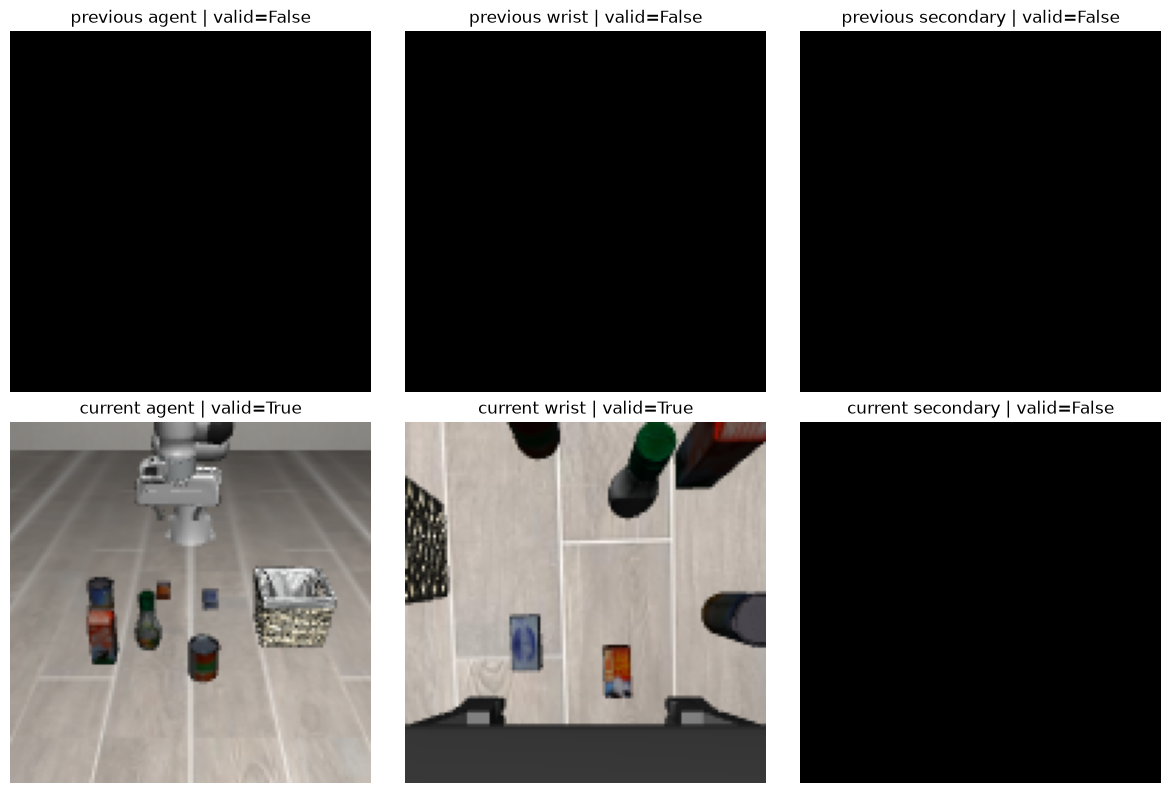

In [5]:
slot_labels = [
    'previous agent', 'previous wrist', 'previous secondary',
    'current agent', 'current wrist', 'current secondary',
]
decoded_slots = []
png_signature = b'\x89PNG\r\n\x1a\n'
for payload in sample['image_slot_jpegs']:
    assert payload.startswith(png_signature), payload[:12]
    with Image.open(io.BytesIO(payload)) as image:
        decoded_slots.append(np.asarray(image.convert('RGB')).copy())

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for index, (ax, image, label) in enumerate(zip(axes.flat, decoded_slots, slot_labels)):
    valid = bool(sample['image_slot_mask'][index])
    ax.imshow(image)
    ax.set_title(f'{label} | valid={valid}')
    ax.axis('off')
    if not valid:
        ax.patch.set_alpha(0.35)
plt.tight_layout()
print('All selected payloads are PNG:', True)

## 4. Inspect Qwen KV and T5 language features

These checks establish shape, finiteness, and non-degenerate values. They cannot prove that a semantic embedding is ideal, but they catch empty, NaN, all-zero, and incorrectly indexed features.

In [6]:
def tensor_summary(name: str, tensor: torch.Tensor) -> dict:
    values = tensor.detach().float().cpu()
    return {
        'name': name,
        'shape': tuple(tensor.shape),
        'stored_dtype': str(tensor.dtype),
        'finite': bool(torch.isfinite(values).all()),
        'mean': float(values.mean()),
        'std': float(values.std()),
        'l2_norm': float(values.norm()),
        'zero_fraction': float((values == 0).float().mean()),
    }

feature_rows = [
    tensor_summary('qwen_kv', sample['qwen_kv']),
    tensor_summary('valid_t5_tokens', sample['lang_tokens'][sample['lang_mask']]),
]
show_table(feature_rows)
assert all(row['finite'] for row in feature_rows)
assert all(row['l2_norm'] > 0 for row in feature_rows)

shard_qwen = selected_shard['qwen_kv'].float().flatten(1)
qwen_norm = torch.nn.functional.normalize(shard_qwen, dim=-1)
qwen_cosine_to_first = qwen_norm @ qwen_norm[0]
print('Qwen cosine similarity to sample 0:')
cosine_values = qwen_cosine_to_first.numpy()
show_table([{
    'count': len(cosine_values),
    'min': float(cosine_values.min()),
    'mean': float(cosine_values.mean()),
    'max': float(cosine_values.max()),
    'std': float(cosine_values.std()),
}])
print('Unique T5 instructions in shard:', len(selected_shard['lang_tokens']))
print('Feature health checks: PASS')

name,shape,stored_dtype,finite,mean,std,l2_norm,zero_fraction
qwen_kv,"(1, 2048)",torch.bfloat16,True,-0.002853556,1.126259,50.95635,0
valid_t5_tokens,"(12, 4096)",torch.bfloat16,True,5.103609e-06,0.09545567,21.1625,0.0004475912


Qwen cosine similarity to sample 0:


count,min,mean,max,std
32,0.9995857,0.9997563,1.000001,9.221187e-05


Unique T5 instructions in shard: 1
Feature health checks: PASS


## 5. Exact comparison against the original HDF5 demonstration

The HDF5 handle is used only inside the `with` block; all required arrays are copied into NumPy arrays before the file closes. The cache state and every valid action target are reconstructed independently from raw LIBERO fields.

In [7]:
metadata_root = Path(suite_metadata[SELECTED_SUITE]['root']).expanduser()
source_root = (
    Path(SOURCE_ROOT_OVERRIDE).expanduser().resolve()
    if SOURCE_ROOT_OVERRIDE is not None
    else (metadata_root if metadata_root.is_absolute() else REPO_ROOT / metadata_root).resolve()
)
episode_file_stem, demo_name = sample['episode_id'].rsplit(':', 1)
source_file = source_root / SELECTED_SUITE / f'{episode_file_stem}.hdf5'
step = int(sample['step_idx'])
assert source_file.exists(), source_file

with h5py.File(source_file, 'r') as handle:
    demo_root = handle['data'] if 'data' in handle else handle
    demo = demo_root[demo_name]
    obs = demo['obs']
    position_key = 'ee_pos' if 'ee_pos' in obs else 'robot0_eef_pos'
    orientation_key = 'ee_ori' if 'ee_ori' in obs else 'robot0_eef_quat'
    gripper_key = 'gripper_states' if 'gripper_states' in obs else 'robot0_gripper_qpos'
    primary_key = 'agentview_rgb' if 'agentview_rgb' in obs else 'agentview_image'
    wrist_key = next((key for key in ('eye_in_hand_rgb', 'robot0_eye_in_hand_image') if key in obs), None)
    raw_position = np.asarray(obs[position_key][step], dtype=np.float32).copy()
    raw_orientation = np.asarray(obs[orientation_key][step], dtype=np.float32).copy()
    raw_fingers = np.asarray(obs[gripper_key][step], dtype=np.float32).copy()
    raw_actions_all = np.asarray(demo['actions'], dtype=np.float32)[:, :7].copy()
    raw_primary = np.asarray(obs[primary_key][step]).copy()
    raw_wrist = None if wrist_key is None else np.asarray(obs[wrist_key][step]).copy()

expected_state = np.concatenate([
    raw_position[:3],
    libero_orientation_to_ortho6d(raw_orientation),
    raw_fingers[:2],
]).astype(np.float32)
cached_state = sample['state'].numpy()

valid_steps = min(64, len(raw_actions_all) - step)
expected_encoded_actions = libero_action_to_rdt(raw_actions_all[step:step + valid_steps])
cached_actions = sample['actions'].numpy()
cached_time_mask = sample['action_time_mask'].numpy().astype(bool)
decoded_cached_actions = rdt_action_to_libero(cached_actions[:valid_steps])

expected_primary = libero_image_to_rgb(raw_primary)
expected_wrist = None if raw_wrist is None else libero_image_to_rgb(raw_wrist)
current_primary_slot = decoded_slots[-3]
current_wrist_slot = decoded_slots[-2]

comparison = {
    'state_max_abs_error': float(np.max(np.abs(cached_state - expected_state))),
    'encoded_action_max_abs_error': float(np.max(np.abs(cached_actions[:valid_steps] - expected_encoded_actions))),
    'decoded_raw_action_max_abs_error': float(np.max(np.abs(decoded_cached_actions - raw_actions_all[step:step + valid_steps]))),
    'raw_gripper_max_abs_error': float(np.max(np.abs(cached_actions[:valid_steps, 9] - raw_actions_all[step:step + valid_steps, 6]))),
    'time_mask_matches_valid_horizon': bool(cached_time_mask[:valid_steps].all() and not cached_time_mask[valid_steps:].any()),
    'padded_actions_are_zero': bool(np.all(cached_actions[~cached_time_mask] == 0)),
    'current_agent_png_pixel_exact': bool(np.array_equal(current_primary_slot, expected_primary)),
    'current_wrist_png_pixel_exact': bool(expected_wrist is None or np.array_equal(current_wrist_slot, expected_wrist)),
}
print('Source:', source_file)
print('Demo / step:', demo_name, step)
show_table([{'check': key, 'value': value} for key, value in comparison.items()])

assert comparison['state_max_abs_error'] < 1e-6
assert comparison['encoded_action_max_abs_error'] < 1e-6
assert comparison['decoded_raw_action_max_abs_error'] < 1e-5
assert comparison['raw_gripper_max_abs_error'] == 0.0
assert comparison['time_mask_matches_valid_horizon']
assert comparison['padded_actions_are_zero']
assert comparison['current_agent_png_pixel_exact']
assert comparison['current_wrist_png_pixel_exact']
print('Exact source comparison: PASS')

Source: /home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_object/pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5
Demo / step: demo_0 0


check,value
state_max_abs_error,8.568168e-08
encoded_action_max_abs_error,0
decoded_raw_action_max_abs_error,3.72529e-09
raw_gripper_max_abs_error,0
time_mask_matches_valid_horizon,True
padded_actions_are_zero,True
current_agent_png_pixel_exact,True
current_wrist_png_pixel_exact,True


Exact source comparison: PASS


## 6. Inspect the selected 11D state

In [8]:
state_names = [
    'x', 'y', 'z',
    'rot6d_0', 'rot6d_1', 'rot6d_2', 'rot6d_3', 'rot6d_4', 'rot6d_5',
    'raw_finger_0', 'raw_finger_1',
]
state_rows = [
    {
        'dimension': name,
        'source_reconstructed': float(expected_state[index]),
        'cached': float(cached_state[index]),
        'absolute_error': float(abs(expected_state[index] - cached_state[index])),
        'mask': float(sample['state_dim_mask'][index]),
    }
    for index, name in enumerate(state_names)
]
show_table(state_rows)

dimension,source_reconstructed,cached,absolute_error,mask
x,-0.1346122,-0.1346122,0,1
y,-0.03159367,-0.03159367,0,1
z,0.2608725,0.2608725,0,1
rot6d_0,0.9987347,0.9987347,0,1
rot6d_1,-0.02860667,-0.02860668,3.72529e-09,1
rot6d_2,-0.0413609,-0.0413609,0,1
rot6d_3,-0.02833956,-0.02833956,0,1
rot6d_4,-0.9995736,-0.9995736,0,1
rot6d_5,0.007030324,0.007030409,8.568168e-08,1
raw_finger_0,0.03610362,0.03610362,0,1


## 7. Plot the 64-command target and compare it with raw HDF5 actions

For an unambiguous visual comparison, the black line is the source HDF5 command and the orange markers are the cached 10D command decoded back to raw 7D. Exact agreement means the markers lie on the black path.

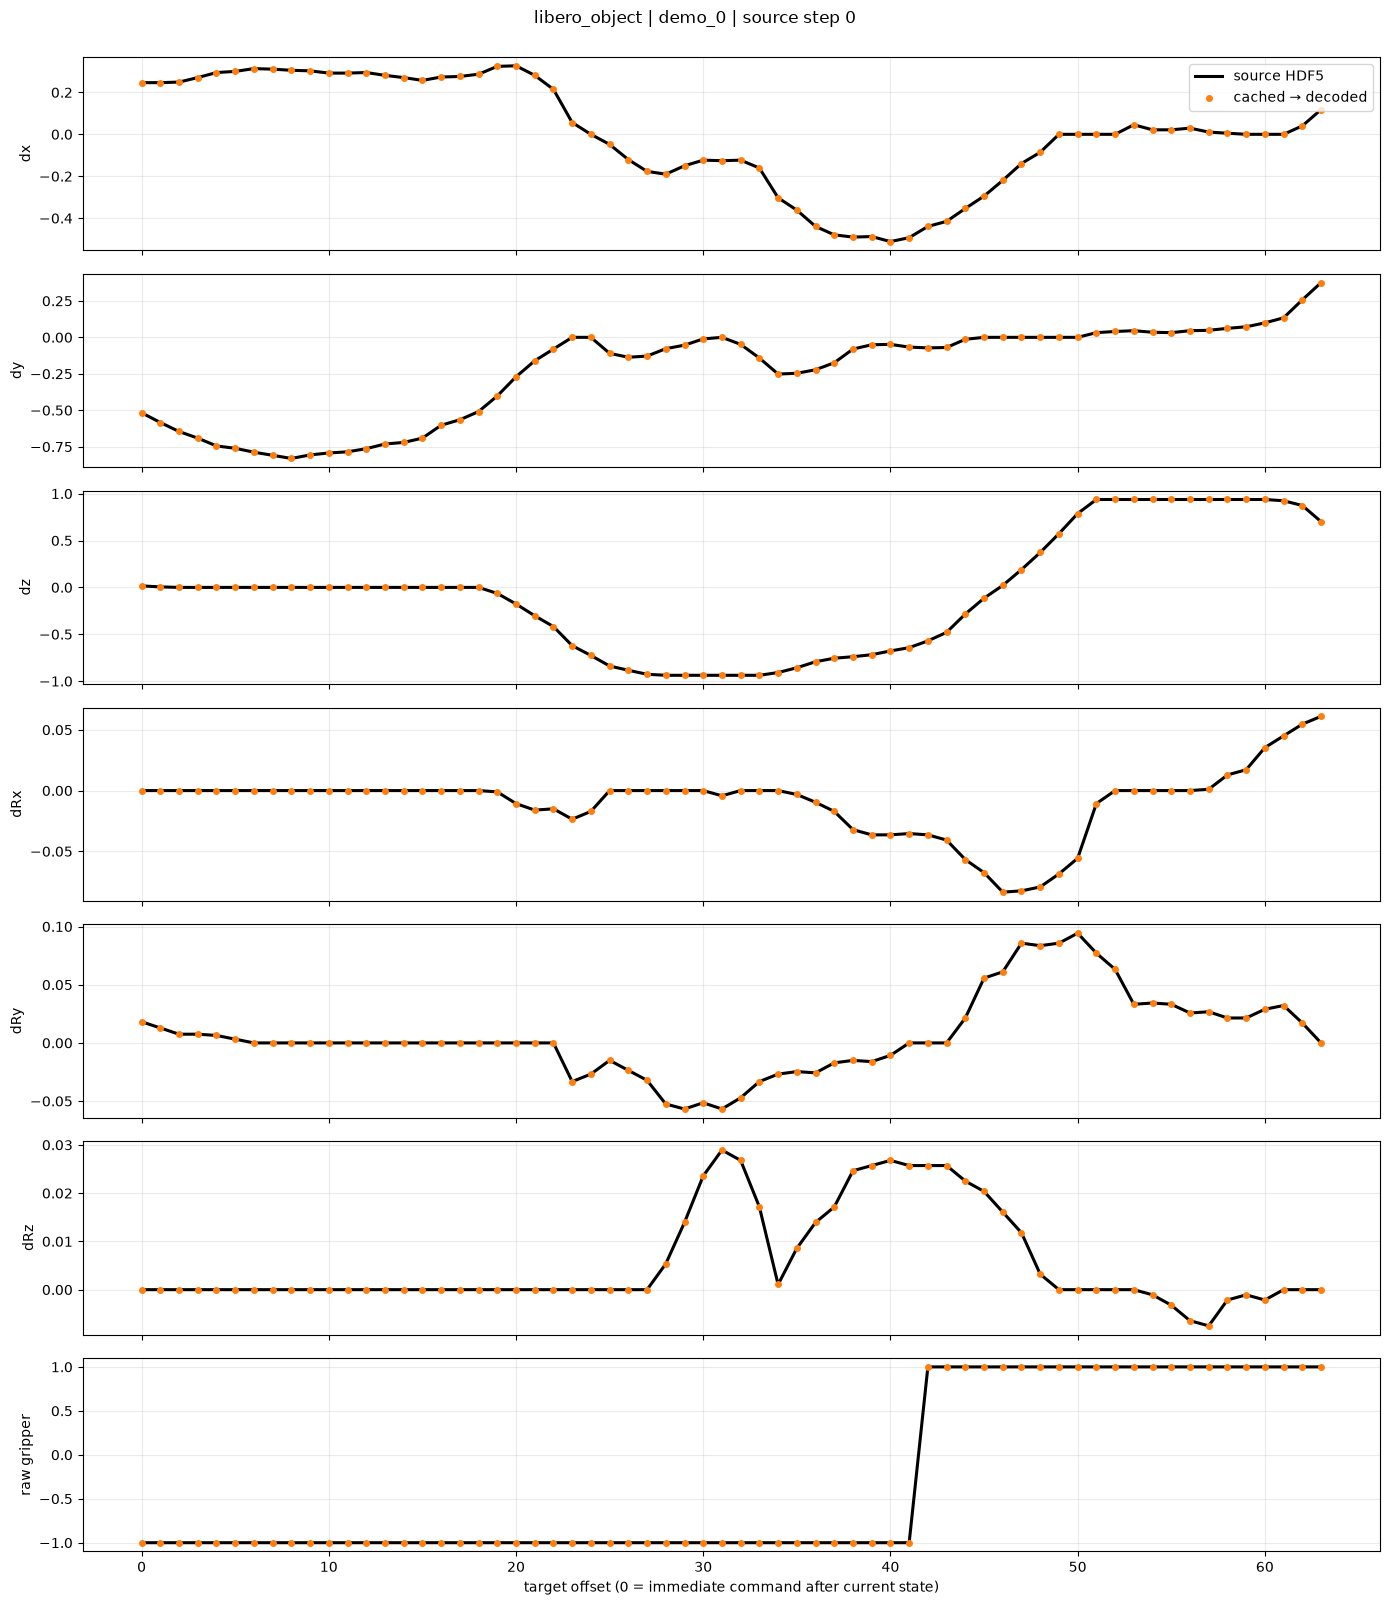

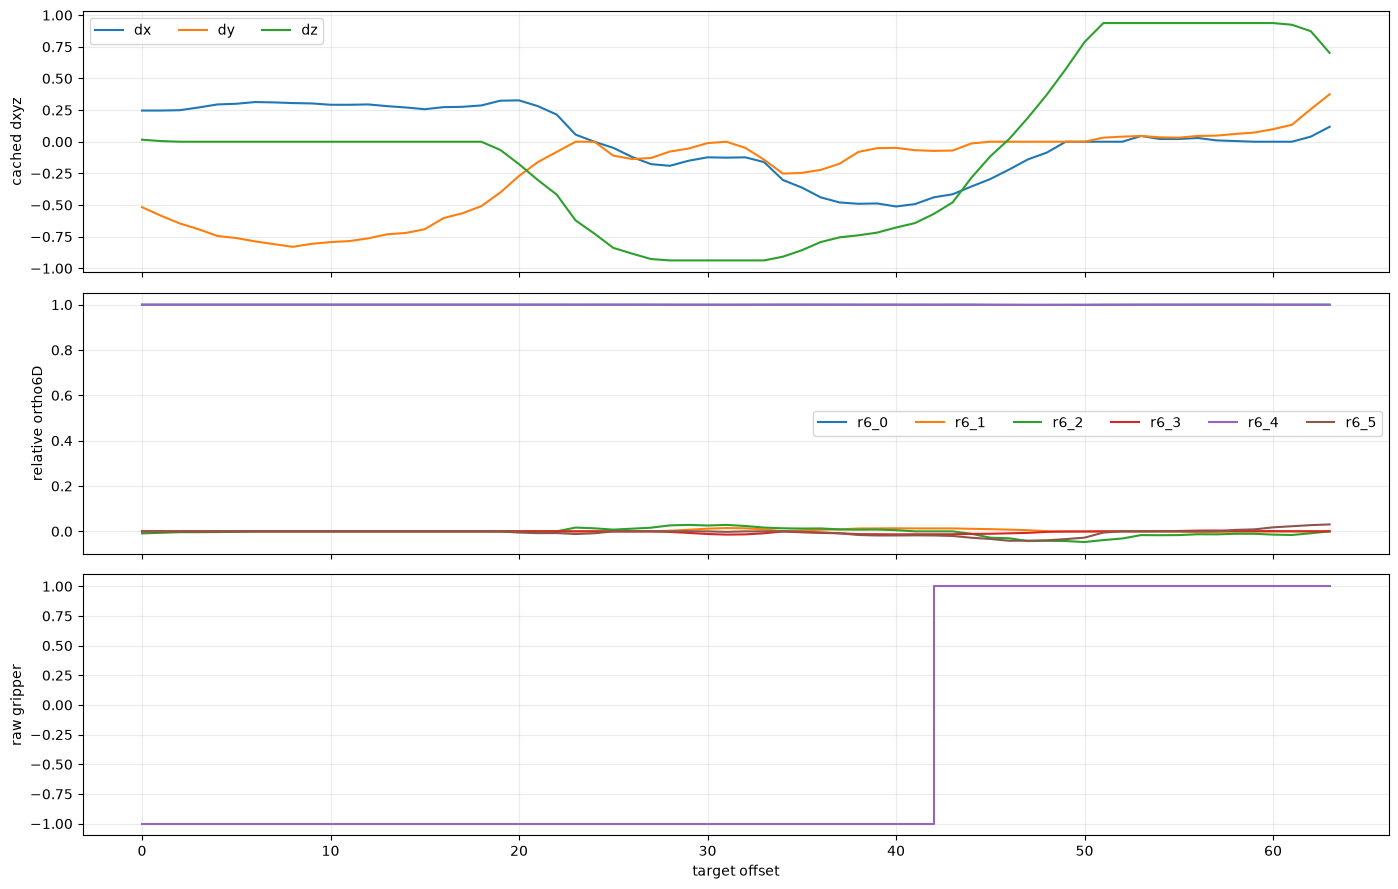

In [9]:
raw_action_names = ['dx', 'dy', 'dz', 'dRx', 'dRy', 'dRz', 'raw gripper']
source_raw_horizon = raw_actions_all[step:step + valid_steps]
x_axis = np.arange(valid_steps)
fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
for dim, ax in enumerate(axes):
    ax.plot(x_axis, source_raw_horizon[:, dim], color='black', linewidth=2.2, label='source HDF5')
    ax.scatter(x_axis, decoded_cached_actions[:, dim], color='tab:orange', s=16, zorder=3, label='cached → decoded')
    ax.set_ylabel(raw_action_names[dim])
    ax.grid(alpha=0.25)
    if dim == 0:
        ax.legend(loc='upper right')
axes[-1].set_xlabel('target offset (0 = immediate command after current state)')
fig.suptitle(f'{SELECTED_SUITE} | {demo_name} | source step {step}', y=1.0)
plt.tight_layout()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(cached_actions[:valid_steps, :3])
axes[0].set_ylabel('cached dxyz')
axes[0].legend(['dx', 'dy', 'dz'], ncol=3)
axes[1].plot(cached_actions[:valid_steps, 3:9])
axes[1].set_ylabel('relative ortho6D')
axes[1].legend([f'r6_{i}' for i in range(6)], ncol=6)
axes[2].step(x_axis, cached_actions[:valid_steps, 9], where='post', color='tab:purple')
axes[2].set_ylabel('raw gripper')
axes[2].set_xlabel('target offset')
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()

## 8. Rotation geometry checks

Ground-truth ortho6D values were constructed from valid rotations. Their reconstructed matrices should satisfy `R.T @ R = I` and `det(R) = +1`.

In [10]:
def rotation_geometry_summary(ortho6d: np.ndarray) -> dict:
    matrices = ortho6d_to_rotation_matrix(ortho6d).astype(np.float64)
    identity = np.eye(3)
    orthogonality = np.linalg.norm(
        np.swapaxes(matrices, -1, -2) @ matrices - identity,
        axis=(-2, -1),
    )
    determinants = np.linalg.det(matrices)
    return {
        'count': int(np.prod(matrices.shape[:-2])),
        'max_orthogonality_error': float(np.max(orthogonality)),
        'max_abs_det_minus_1': float(np.max(np.abs(determinants - 1.0))),
        'min_determinant': float(np.min(determinants)),
        'max_determinant': float(np.max(determinants)),
    }

rotation_rows = [
    {'field': 'state absolute rotation', **rotation_geometry_summary(cached_state[None, 3:9])},
    {'field': 'action relative rotations', **rotation_geometry_summary(cached_actions[:valid_steps, 3:9])},
]
show_table(rotation_rows)
assert all(row['max_orthogonality_error'] < 1e-5 for row in rotation_rows)
assert all(row['max_abs_det_minus_1'] < 1e-5 for row in rotation_rows)
print('Rotation geometry: PASS')

field,count,max_orthogonality_error,max_abs_det_minus_1,min_determinant,max_determinant
state absolute rotation,1,5.505865e-08,1.258031e-08,1,1
action relative rotations,64,8.830328e-08,7.345738e-08,0.9999999,1


Rotation geometry: PASS


## 9. Verify the exact batch consumed by training

This confirms that the online-SigLIP collator keeps the 11D state, 10D action, two raw fingers, and raw gripper command unchanged. SigLIP itself is computed online during training and is therefore not expected inside these shards.

In [11]:
cfg = load_config(CONFIG_PATH)
collator = RDTOnlineSiglipBatchCollator(
    max_lang_tokens=cfg.model.max_lang_tokens,
    pred_horizon=cfg.model.pred_horizon,
    feature_dim=cfg.model.qwen_hidden_size,
    state_dim=cfg.model.state_dim,
    action_dim=cfg.model.action_dim,
    lang_token_dim=cfg.model.lang_token_dim,
    qwen_kv_dim=cfg.model.qwen_kv_dim,
    convert_cached_gripper_closed_to_open=cfg.model.convert_cached_gripper_closed_to_open,
)
mini_samples = [dataset[index] for index in range(global_sample_index, min(global_sample_index + 4, len(dataset)))]
batch = collator(mini_samples)
batch_shapes = {key: tuple(value.shape) for key, value in batch.items() if torch.is_tensor(value)}
show_table([{'key': key, 'shape': shape} for key, shape in batch_shapes.items()])

assert batch['state'].shape[1] == LIBERO_STATE_DIM
assert batch['actions'].shape[1:] == (cfg.model.pred_horizon, LIBERO_ACTION_DIM)
torch.testing.assert_close(batch['state'][0], mini_samples[0]['state'])
torch.testing.assert_close(batch['actions'][0, :, 9], mini_samples[0]['actions'][:, 9])
torch.testing.assert_close(batch['state'][0, 9:11], mini_samples[0]['state'][9:11])
assert cfg.model.convert_cached_gripper_closed_to_open is False
print('Training collator contract: PASS')

key,shape
qwen_kv,"(4, 1, 2048)"
lang_tokens,"(4, 128, 4096)"
lang_mask,"(4, 128)"
state,"(4, 11)"
state_dim_mask,"(4, 11)"
actions,"(4, 64, 10)"
action_time_mask,"(4, 64)"
action_dim_mask,"(4, 10)"
ctrl_freq,"(4,)"
image_slot_mask,"(4, 6)"


Training collator contract: PASS


## 10. Audit the first 10 training shards from every requested suite

Increase `SHARDS_PER_SUITE_TO_AUDIT` in the configuration cell for a wider scan. This checks shapes, masks, finiteness, PNG signatures, padding, and rotation geometry without loading the vision/language models.

In [12]:
def audit_shard(suite: str, split_root: Path, manifest_row: dict, row_index: int) -> dict:
    path = split_root / manifest_row['path']
    record = torch.load(path, map_location='cpu', weights_only=False)
    errors = []
    count = int(record['num_samples'])

    expected_shapes = {
        'state': (count, 11),
        'state_dim_mask': (count, 11),
        'actions': (count, 64, 10),
        'action_time_mask': (count, 64),
        'action_dim_mask': (count, 10),
        'qwen_kv': (count, 1, 2048),
    }
    for key, expected in expected_shapes.items():
        if tuple(record[key].shape) != expected:
            errors.append(f'{key}={tuple(record[key].shape)} expected={expected}')

    for key in ('state', 'actions', 'qwen_kv'):
        if not bool(torch.isfinite(record[key].float()).all()):
            errors.append(f'{key} contains NaN/Inf')
    for tokens in record['lang_tokens']:
        if not bool(torch.isfinite(tokens.float()).all()) or float(tokens.float().norm()) == 0.0:
            errors.append('invalid T5 token tensor')
            break

    time_mask = record['action_time_mask'].bool()
    actions = record['actions'].float()
    if bool((time_mask[:, 1:] & ~time_mask[:, :-1]).any()):
        errors.append('action_time_mask is not a valid prefix')
    if bool((actions[~time_mask] != 0).any()):
        errors.append('padded actions are nonzero')
    if not bool((record['state_dim_mask'] == 1).all()):
        errors.append('state_dim_mask is not all ones')
    if not bool((record['action_dim_mask'] == 1).all()):
        errors.append('action_dim_mask is not all ones')
    if any(not payload.startswith(png_signature) for payload in record['image_jpegs']):
        errors.append('non-PNG image payload found')

    valid_actions = actions[time_mask].numpy()
    state_rotation = rotation_geometry_summary(record['state'][:, 3:9].numpy())
    action_rotation = rotation_geometry_summary(valid_actions[:, 3:9])
    if state_rotation['max_orthogonality_error'] >= 1e-5:
        errors.append('state rotation geometry invalid')
    if action_rotation['max_orthogonality_error'] >= 1e-5:
        errors.append('action rotation geometry invalid')

    return {
        'suite': suite,
        'shard': row_index,
        'samples': count,
        'valid_targets': int(time_mask.sum()),
        'png_payloads': len(record['image_jpegs']),
        'qwen_norm_mean': float(record['qwen_kv'].float().flatten(1).norm(dim=1).mean()),
        'max_state_rot_error': state_rotation['max_orthogonality_error'],
        'max_action_rot_error': action_rotation['max_orthogonality_error'],
        'status': 'PASS' if not errors else 'FAIL',
        'errors': '; '.join(errors),
    }

audit_rows = []
for suite in SUITES:
    split_root = CACHE_ROOT / suite / 'train'
    rows = read_manifest(split_root / 'manifest.jsonl')
    for row_index, manifest_row in enumerate(rows[:SHARDS_PER_SUITE_TO_AUDIT]):
        audit_rows.append(audit_shard(suite, split_root, manifest_row, row_index))

show_table(audit_rows)
audit_summary = []
for suite in SUITES:
    rows = [row for row in audit_rows if row['suite'] == suite]
    audit_summary.append({
        'suite': suite,
        'shards': len(rows),
        'samples': sum(row['samples'] for row in rows),
        'valid_targets': sum(row['valid_targets'] for row in rows),
        'failures': sum(row['status'] != 'PASS' for row in rows),
    })
show_table(audit_summary)
failed_audits = [row for row in audit_rows if row['status'] != 'PASS']
assert not failed_audits, failed_audits
print('Multi-suite shard audit: PASS')

suite,shard,samples,valid_targets,png_payloads,qwen_norm_mean,max_state_rot_error,max_action_rot_error,status,errors
libero_10,0,32,2048,65,50.96284,7.930635e-08,9.175904e-08,PASS,
libero_10,1,32,2048,65,50.9812,8.443456e-08,8.325907e-08,PASS,
libero_10,2,32,2048,65,50.9982,8.588732e-08,8.107331e-08,PASS,
libero_10,3,32,2048,65,50.97565,9.148046e-08,8.170524e-08,PASS,
libero_10,4,32,2048,67,50.9863,8.913828e-08,9.175904e-08,PASS,
libero_10,5,32,2048,67,50.9919,7.866603e-08,8.325907e-08,PASS,
libero_10,6,32,2048,67,50.9998,9.041631e-08,8.481657e-08,PASS,
libero_10,7,32,2048,67,51.00109,9.029536e-08,8.170524e-08,PASS,
libero_10,8,32,2048,67,50.99654,9.626924e-08,7.756868e-08,PASS,
libero_10,9,32,2048,67,50.9898,8.530145e-08,8.70607e-08,PASS,


suite,shards,samples,valid_targets,failures
libero_10,10,320,20480,0
libero_spatial,10,320,15978,0
libero_goal,10,320,19814,0
libero_object,10,320,20411,0


Multi-suite shard audit: PASS


## Final verdict

In [13]:
final_checks = {
    'all four suite metadata contracts': True,
    'selected state equals source HDF5': comparison['state_max_abs_error'] < 1e-6,
    'selected action horizon equals source HDF5': comparison['encoded_action_max_abs_error'] < 1e-6,
    '10D to raw 7D round trip': comparison['decoded_raw_action_max_abs_error'] < 1e-5,
    'raw gripper unchanged': comparison['raw_gripper_max_abs_error'] == 0.0,
    'agent PNG pixel exact': comparison['current_agent_png_pixel_exact'],
    'wrist PNG pixel exact': comparison['current_wrist_png_pixel_exact'],
    'Qwen and T5 finite/nonzero': all(row['finite'] and row['l2_norm'] > 0 for row in feature_rows),
    'training collator preserves raw fields': True,
    'first requested shards pass': not failed_audits,
}
verdict_rows = [{'check': key, 'passed': passed} for key, passed in final_checks.items()]
show_table(verdict_rows)
assert all(final_checks.values())
print('CACHE AUDIT PASSED — ready for a small overfitting experiment.')

check,passed
all four suite metadata contracts,True
selected state equals source HDF5,True
selected action horizon equals source HDF5,True
10D to raw 7D round trip,True
raw gripper unchanged,True
agent PNG pixel exact,True
wrist PNG pixel exact,True
Qwen and T5 finite/nonzero,True
training collator preserves raw fields,True
first requested shards pass,True


CACHE AUDIT PASSED — ready for a small overfitting experiment.


# Small fixed-subset overfitting experiment

The experiment below optimizes weighted clean-sample denoising MSE with the non-overlapping one-indexed schedule `1–4: 5`, `5–8: 3`, `9–16: 2`, `17–64: 1`. It evaluates the actual five-step diffusion sampler at step 0 and during training—not only the teacher-forced denoising forward pass.

Real sampled 10D outputs are decoded to the raw 7D LIBERO command before measuring prefix RMSE, per-dimension correlation, sign agreement, saturation, and raw-gripper accuracy/F1. The optional rollout invokes the real LIBERO simulator and writes success rate to the same report.

In [ ]:
import shlex
import subprocess

RUN_OVERFIT = False       # Set True when ready; this loads RDT-1B and SigLIP on CUDA.
RUN_LIBERO_ROLLOUT = False
OVERFIT_SUITE = SELECTED_SUITE
OVERFIT_OUTPUT = REPO_ROOT / 'outputs/libero_cached_overfit' / OVERFIT_SUITE
OVERFIT_SAMPLES = 8
OVERFIT_BATCH_SIZE = 2
OVERFIT_STEPS = 500
SAMPLE_EVERY = 100
SAMPLING_REPEATS = 3
INFERENCE_STEPS = 5
BASE_ARTIFACT: Path | None = None  # Optional merged/full RDT base artifact.
INIT_ARTIFACT: Path | None = None  # Optional compatible LoRA + interface artifact.
SIGLIP_MODEL_ID: str | None = None # Defaults to cache metadata.

overfit_command = [
    sys.executable, str(REPO_ROOT / 'scripts/overfit_libero_cached.py'),
    '--config', str(CONFIG_PATH),
    '--cache-root', str(CACHE_ROOT),
    '--suite', OVERFIT_SUITE,
    '--output-dir', str(OVERFIT_OUTPUT),
    '--num-samples', str(OVERFIT_SAMPLES),
    '--batch-size', str(OVERFIT_BATCH_SIZE),
    '--steps', str(OVERFIT_STEPS),
    '--sample-every', str(SAMPLE_EVERY),
    '--sampling-repeats', str(SAMPLING_REPEATS),
    '--inference-steps', str(INFERENCE_STEPS),
]
if BASE_ARTIFACT is not None:
    overfit_command += ['--base-artifact', str(BASE_ARTIFACT)]
if INIT_ARTIFACT is not None:
    overfit_command += ['--init-artifact', str(INIT_ARTIFACT)]
if SIGLIP_MODEL_ID is not None:
    overfit_command += ['--siglip-model-id', SIGLIP_MODEL_ID]
if RUN_LIBERO_ROLLOUT:
    overfit_command += [
        '--run-rollout',
        '--rollout-task-id', '0',
        '--rollout-episodes-per-task', '2',
        '--rollout-action-chunk', '1',
    ]

print(shlex.join(overfit_command))
if RUN_OVERFIT:
    subprocess.run(overfit_command, cwd=REPO_ROOT, check=True)
else:
    print('Dry run only. Set RUN_OVERFIT=True to start training.')

## Plot real-sampling progress

Run this after the experiment has created `report.json`. Correlation can be `None` for a dimension that is constant over the tiny subset; that is mathematically undefined rather than a failure. Saturation is measured after decoding and clipping to the raw LIBERO command range.

In [ ]:
overfit_report_path = OVERFIT_OUTPUT / 'report.json'
if not overfit_report_path.exists():
    print('No report yet:', overfit_report_path)
else:
    overfit_report = read_json(overfit_report_path)
    sampling_events = [event for event in overfit_report['history'] if 'real_sampling' in event]
    rmse_rows = []
    for event in sampling_events:
        for horizon in (1, 4, 8, 64):
            values = event['real_sampling']['horizon_rmse'][str(horizon)]
            if values is not None:
                rmse_rows.append({'step': event['step'], 'horizon': horizon, **values})
    show_table(rmse_rows)

    fig, ax = plt.subplots(figsize=(10, 5))
    for horizon in (1, 4, 8, 64):
        rows = [row for row in rmse_rows if row['horizon'] == horizon]
        ax.plot(
            [row['step'] for row in rows],
            [row['command_rmse_7d'] for row in rows],
            marker='o', label=f'prefix {horizon}',
        )
    ax.set_xlabel('optimizer step')
    ax.set_ylabel('sampled raw-command RMSE (7D)')
    ax.set_title('Real diffusion sampling—not teacher-forced denoising')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()

    final_sampling = sampling_events[-1]['real_sampling']
    dimension_rows = [
        {
            'dimension': name,
            'correlation': final_sampling['per_dimension_correlation'][name],
            'sign_agreement': final_sampling['per_dimension_sign_agreement'][name],
            'saturation_fraction': final_sampling['per_dimension_saturation_fraction'][name],
        }
        for name in ('dx', 'dy', 'dz', 'dRx', 'dRy', 'dRz', 'gripper')
    ]
    show_table(dimension_rows)
    show_table([final_sampling['gripper']])
    print('Overall sign agreement:', final_sampling['overall_sign_agreement'])
    print('Overall saturation fraction:', final_sampling['overall_saturation_fraction'])
    if isinstance(overfit_report.get('rollout'), dict) and 'success_rate' in overfit_report['rollout']:
        show_table([{
            'rollout_episodes': overfit_report['rollout']['episodes'],
            'rollout_successes': overfit_report['rollout']['successes'],
            'rollout_success_rate': overfit_report['rollout']['success_rate'],
        }])
    else:
        print('LIBERO rollout was not requested for this run.')